# Lending Club: Screening Peer-Lending Loans for Better Outcomes
## Update 1 — Diagnostic and Descriptive Models

**45-952 End-to-End Business Analytics — Fall 2026**

This notebook is scoped to **Update 1** of the Lending Club case (*Screening
peer-lending loans for better outcomes*): business understanding, data
understanding, descriptive analysis, K-means clustering, and PCA. Predictive
modeling (logistic regression, decision trees) and prescriptive/optimization
work are out of scope here and are addressed in Updates 2 and 3.

Data: `data/loanskpi.csv` (9,578 three-year loans funded by Lending Club,
May 2007–Feb 2010), described in `docs/LoansDataDescr.pdf`. Business context:
`docs/MBA_CreditDefault_Case_Fall2026.pdf`.


## 1. Business Understanding

Lending Club's Executive Committee is weighing several related decisions:

- **Which loan applications to feature to investors** on the platform (the
  core screening decision).
- **How to price interest rates by risk tier** once an applicant is accepted.
- **Which borrower segments to prioritize** for growth outreach.

Three ExCo members care about different outcomes of these decisions:
- **CEO** — return on invested capital (ROIC) for platform investors.
- **CFO** — profit earned from interest (net of Lending Club's cut).
- **CMO** — market share growth against competitors (e.g., Prosper).

**Scope of this analysis:** we focus on the **screening decision** — which
loan applications should be featured to investors in the first place. A
model that reliably flags high-risk applications *before* they are shown to
investors directly serves all three ExCo members: it protects ROIC and
interest profit by avoiding defaults, and it protects market share by
keeping investor returns competitive (an investor base with better
risk-adjusted returns is Lending Club's best growth engine against
competitors like Prosper). Pricing (interest-rate-by-risk-tier) and
portfolio-level optimization build on this same risk model and are deferred
to Updates 2–3.


## 2. Source of Value

Lending Club's key asset is its **historical record of funded loans and
their outcomes** — the terms offered (rate, installment), the borrower's
credit-bureau profile at the time of application, and whether the loan was
ultimately paid back in full or defaulted/charged off.

The value-creation logic for this project:

1. **Learn** the statistical relationship between borrower/loan
   characteristics known *at the time of funding* and the eventual default
   outcome, using this historical sample.
2. **Screen** new applications through that learned relationship *before*
   they are ever shown to investors, flagging high-risk applications.
3. **Improve outcomes** for all three ExCo constituencies: fewer bad loans
   funded improves ROIC and interest profit, and a track record of solid
   investor returns is a durable market-share advantage.

Update 1 lays the groundwork for step 1 — understanding the data and its
structure — before Update 2 builds the actual predictive (classification)
models.


## 3. Data Understanding

### 3.1 Unit of analysis

Each row in `loanskpi.csv` is **one 3-year loan** funded through the
LendingClub.com platform between May 2007 and February 2010 (9,578 loans).

### 3.2 Feature groups and data dynamism

A critical distinction for modeling: which fields are known **at the time of
the funding decision** versus which are only **computed after the loan's
outcome is known**. Using the latter as predictors would leak the answer
into the model.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from pandas.plotting import parallel_coordinates
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

data_path = "../data/loanskpi.csv"
df = pd.read_csv(data_path)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
display(df.head())


Shape: 9578 rows x 17 columns


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,default,tot.payment,principal,interest
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,29847.60,20892.796502,8954.803498
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,8215.92,5958.231659,2257.688341
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,13206.96,8790.257126,4416.702874
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,5844.24,4319.141090,1525.098910
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,3705.12,2415.522565,1289.597435


In [2]:
known_at_application = ['credit.policy', 'purpose', 'int.rate', 'installment',
                         'log.annual.inc', 'dti', 'fico', 'days.with.cr.line',
                         'revol.bal', 'revol.util', 'inq.last.6mths',
                         'delinq.2yrs', 'pub.rec']
target = ['default']
computed_after_outcome = ['tot.payment', 'principal', 'interest']

field_roles = pd.DataFrame({
    'field': known_at_application + target + computed_after_outcome,
    'role': (['Known at application'] * len(known_at_application)
             + ['Target (outcome)']
             + ['Computed after outcome (KPI, not a predictor)'] * len(computed_after_outcome))
})
display(field_roles)


,field,role
0,credit.policy,Known at application
1,purpose,Known at application
2,int.rate,Known at application
3,installment,Known at application
4,log.annual.inc,Known at application
5,dti,Known at application
6,fico,Known at application
7,days.with.cr.line,Known at application
8,revol.bal,Known at application
9,revol.util,Known at application


**Implication for modeling:** `tot.payment`, `principal`, and `interest`
are deterministic functions of `installment`/`int.rate` and the loan's
outcome — they must **never** be used as predictive features for a
funding-decision model (they are provided only to later compute profit,
loss, and ROIC once a screening decision has been made). All descriptive
analysis, clustering, and PCA below use only the 13 fields known at
application time (plus `default` as the outcome for cross-tabulation, never
as a clustering/PCA input).

### 3.3 Which features likely matter most for profitability?

Based on the data description and lending-industry intuition, the fields
most likely to drive eventual profitability are:

- **`fico`** — the borrower's credit score; the single most standard proxy
  for repayment risk.
- **`int.rate`** — already reflects LendingClub's own risk assessment, so it
  is both a feature and a partial "answer key" for risk.
- **`revol.util`** — how much of the available revolving credit is in use;
  a classic over-leverage signal.
- **`dti`** — debt-to-income ratio; captures repayment capacity relative to
  income.
- **`inq.last.6mths`** — recent credit inquiries, a signal of active
  credit-shopping / financial stress.
- **`purpose`** — the stated reason for borrowing (e.g., `small_business`
  loans are inherently riskier than `credit_card` refinancing).

We test these hypotheses empirically in the descriptive analysis below.

### 3.4 Structure, types, and missing values


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  default            9578 non-null   int64  
 14  tot.payment        9578 non-null   float64
 15  principal          9578 non-null   float64
 16  interest           9578 non-null   

In [4]:
display(df.describe(include='all').T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
credit.policy,9578.0,NaN,NaN,NaN,0.80497,0.396245,0.0,1.0,1.0,1.0,1.0
purpose,9578,7,debt_consolidation,3957,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int.rate,9578.0,NaN,NaN,NaN,0.12264,0.026847,0.06,0.1039,0.1221,0.1407,0.2164
installment,9578.0,NaN,NaN,NaN,319.089413,207.071301,15.67,163.77,268.95,432.7625,940.14
log.annual.inc,9578.0,NaN,NaN,NaN,10.932117,0.614813,7.547502,10.558414,10.928884,11.291293,14.528354
dti,9578.0,NaN,NaN,NaN,12.606679,6.88397,0.0,7.2125,12.665,17.95,29.96
fico,9578.0,NaN,NaN,NaN,710.846314,37.970537,612.0,682.0,707.0,737.0,827.0
days.with.cr.line,9578.0,NaN,NaN,NaN,4560.767197,2496.930377,178.958333,2820.0,4139.958333,5730.0,17639.95833
revol.bal,9578.0,NaN,NaN,NaN,16913.963876,33756.189557,0.0,3187.0,8596.0,18249.5,1207359.0
revol.util,9578.0,NaN,NaN,NaN,46.799236,29.014417,0.0,22.6,46.3,70.9,119.0


In [5]:
missing = pd.DataFrame(df.isnull().sum(), columns=['Missing Values'])
missing['% Missing'] = (missing['Missing Values'] / len(df) * 100).round(2)
display(missing)
print(f"\nOverall default rate: {df['default'].mean()*100:.1f}%")


,Missing Values,% Missing
credit.policy,0,0.0
purpose,0,0.0
int.rate,0,0.0
installment,0,0.0
log.annual.inc,0,0.0
dti,0,0.0
fico,0,0.0
days.with.cr.line,0,0.0
revol.bal,0,0.0
revol.util,0,0.0



Overall default rate: 16.0%


## 4. Descriptive Analysis

### 4.1 Categorical variable distributions

`purpose` is the only text-categorical field; `credit.policy` is a binary
underwriting flag.


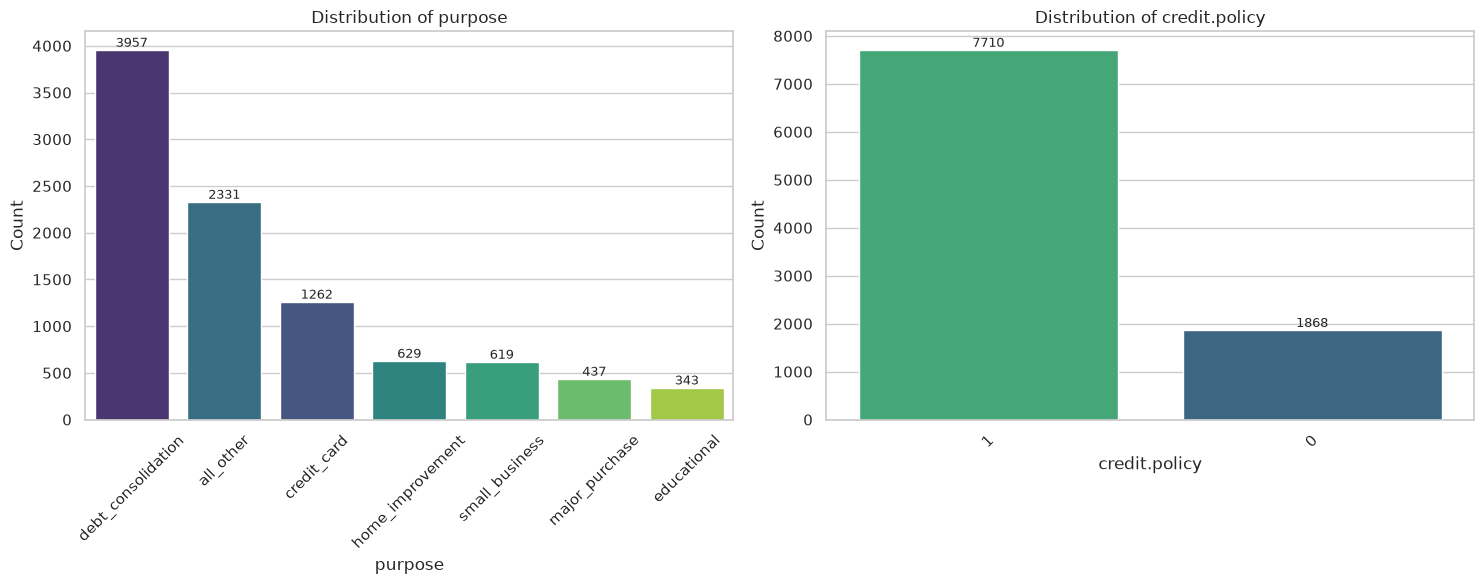

In [6]:
categorical_cols = ['purpose', 'credit.policy']

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(15, 6))
for ax, col in zip(axes, categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, hue=col, palette='viridis', legend=False, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../output/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.2 Numerical variable distributions (application-time fields)

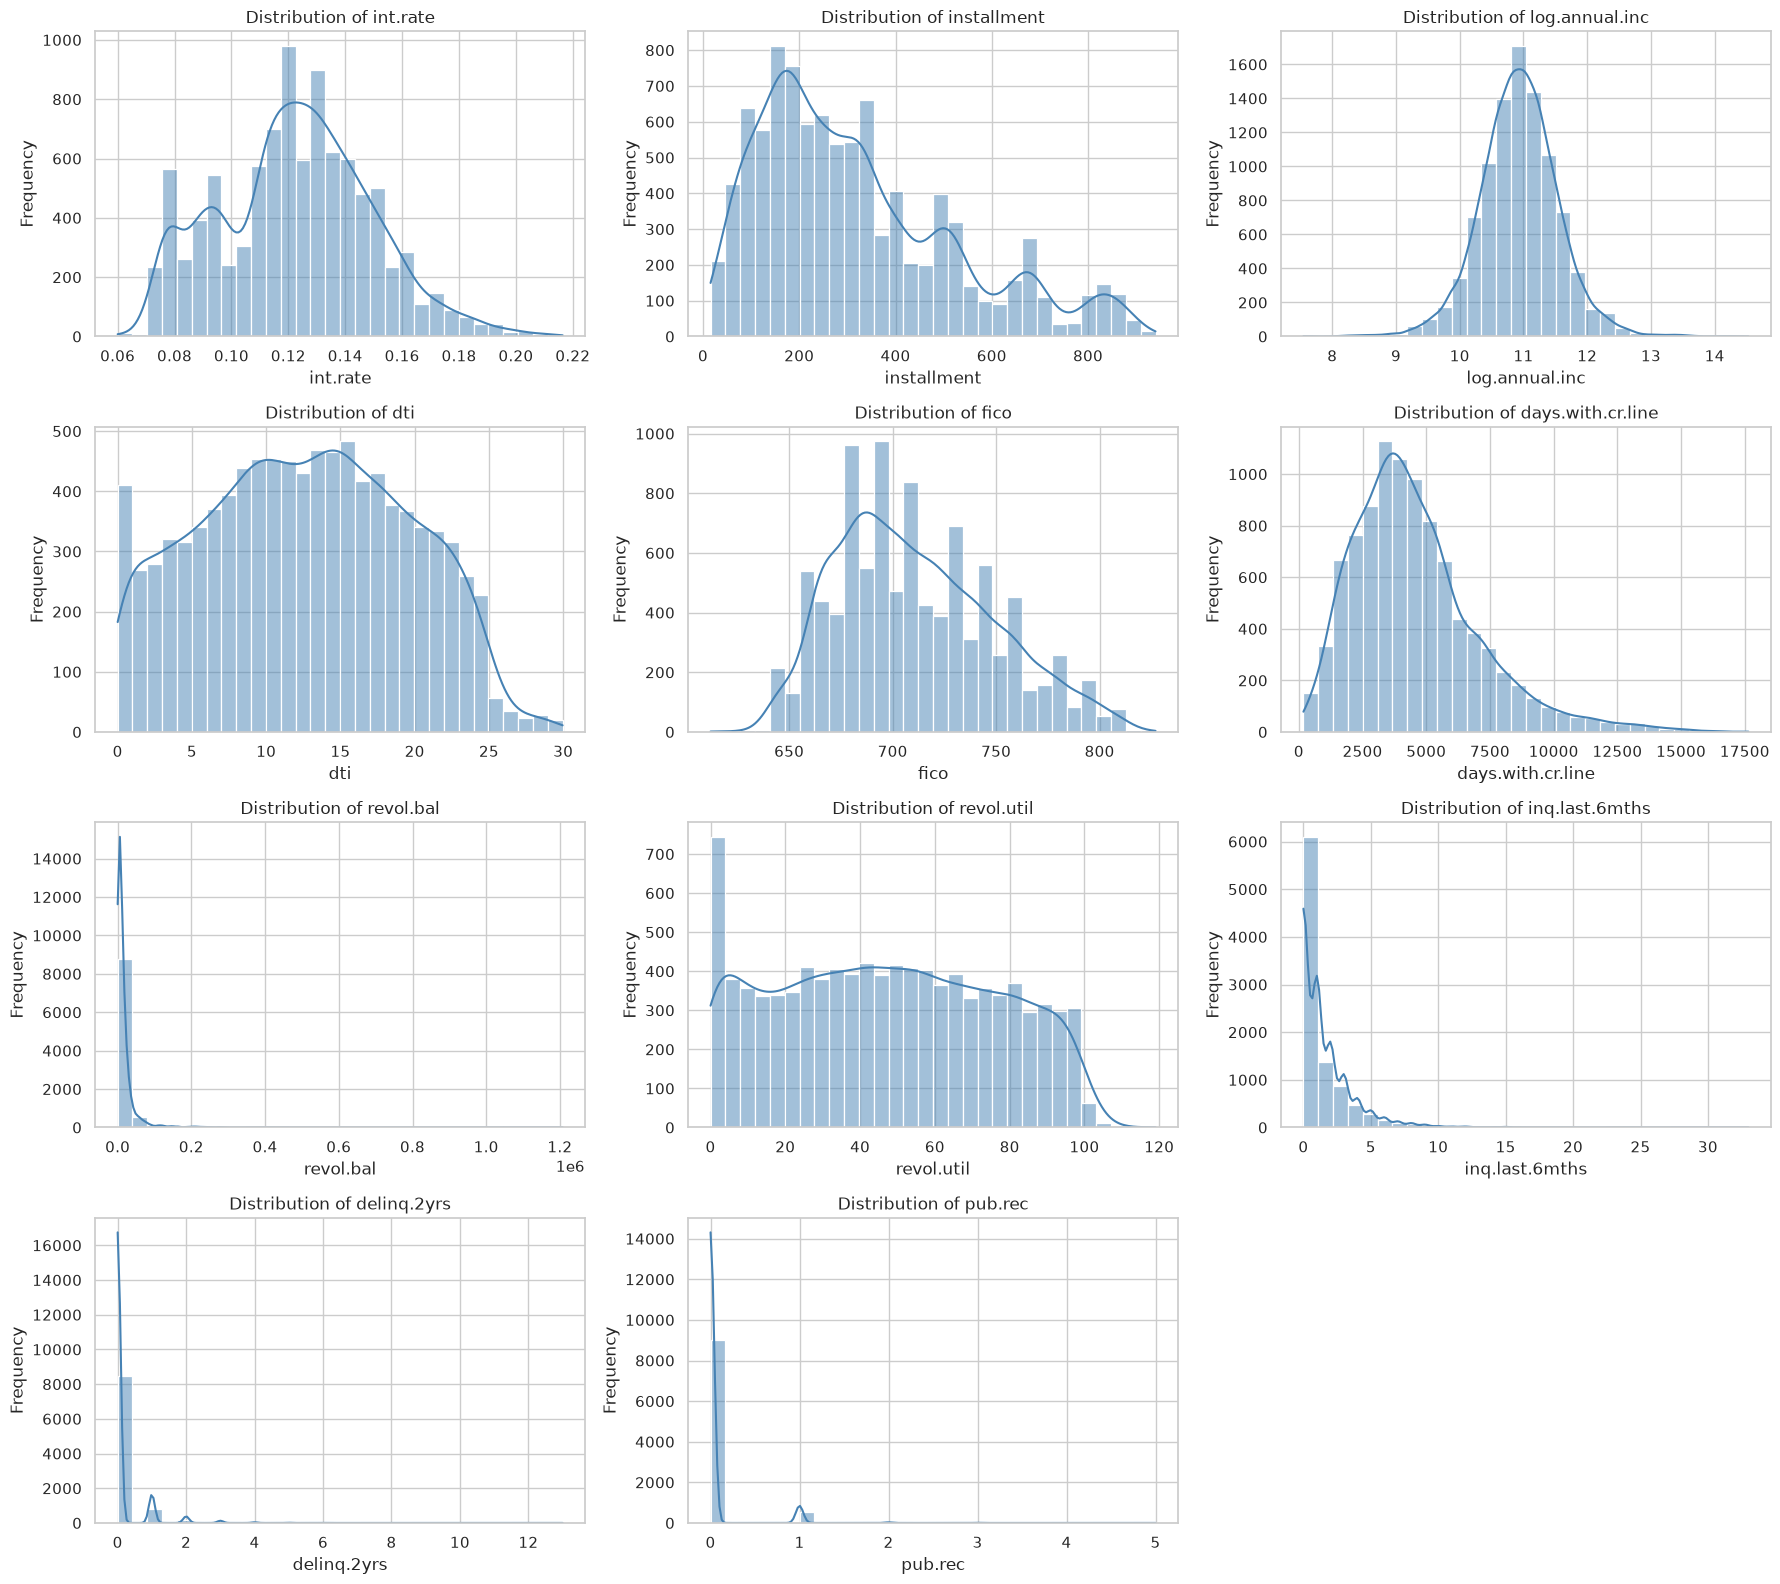

In [7]:
numeric_cols = ['int.rate', 'installment', 'log.annual.inc', 'dti', 'fico',
                'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths',
                'delinq.2yrs', 'pub.rec']

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, bins=30, color='steelblue', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('../output/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


**Observations:** `revol.bal`, `dti`, `days.with.cr.line`, and
`inq.last.6mths` are right-skewed with long tails; `delinq.2yrs` and
`pub.rec` are extremely concentrated at 0 (most borrowers have none) —
these behave more like sparse count/flag variables than continuous ones.
`fico`, `int.rate`, and `log.annual.inc` are closer to bell-shaped.

### 4.3 Correlation structure

Two views: (1) all application-time numeric fields plus `default` and the
post-outcome KPI fields (to show *why* the KPI fields must be excluded from
modeling), and (2) application-time predictors only.


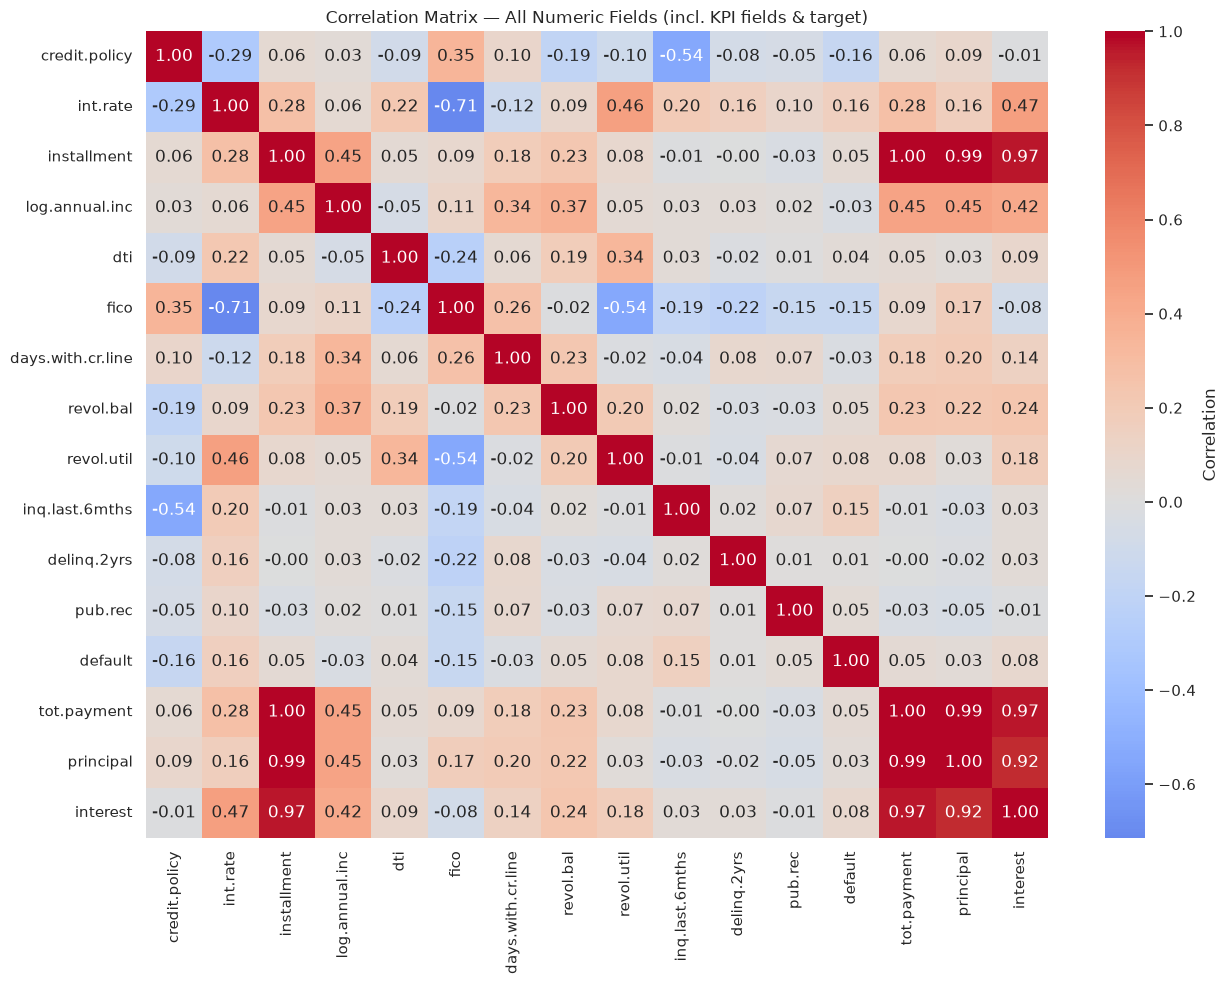

In [8]:
full_numeric = df.select_dtypes(include=[np.number])
corr_full = full_numeric.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_full, annot=True, cmap='coolwarm', fmt=".2f", center=0,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix — All Numeric Fields (incl. KPI fields & target)')
plt.tight_layout()
plt.savefig('../output/correlation_matrix_full.png', dpi=150, bbox_inches='tight')
plt.show()


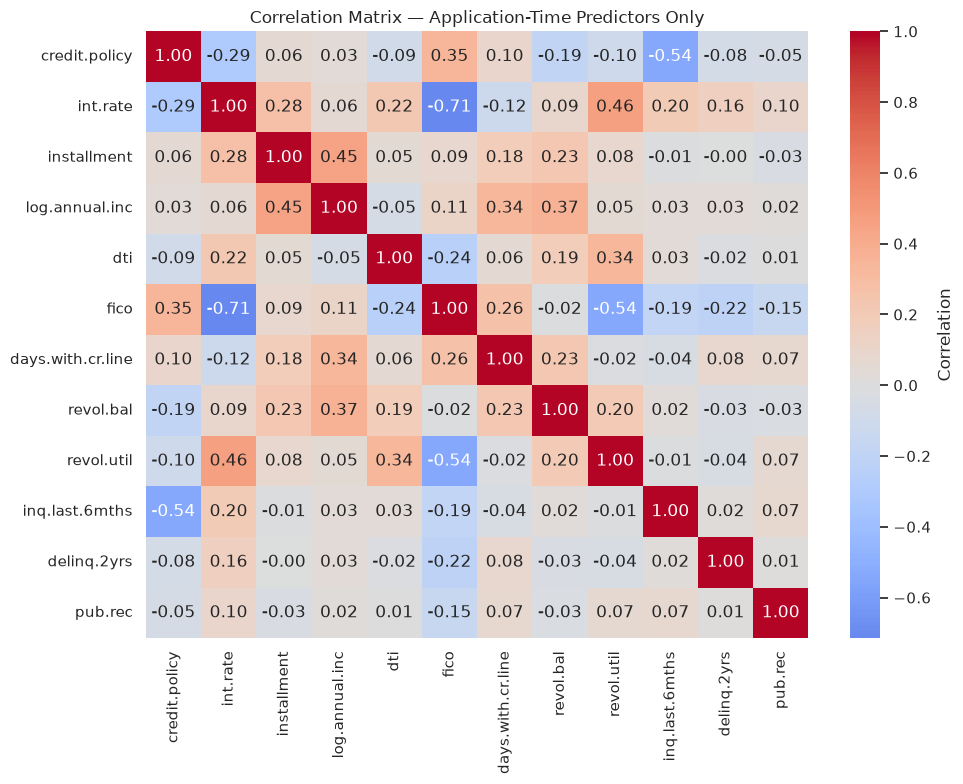

In [9]:
predictor_cols = ['credit.policy', 'int.rate', 'installment', 'log.annual.inc', 'dti',
                   'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
                   'inq.last.6mths', 'delinq.2yrs', 'pub.rec']

corr_predictors = df[predictor_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_predictors, annot=True, cmap='coolwarm', fmt=".2f", center=0,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix — Application-Time Predictors Only')
plt.tight_layout()
plt.savefig('../output/correlation_matrix_predictors.png', dpi=150, bbox_inches='tight')
plt.show()


**Key correlated pairs** (as anticipated by the case):
- `int.rate` vs. `fico`: strongly negative — LendingClub prices risk into
  the rate.
- `int.rate` vs. `revol.util`: positive — utilization is part of the risk
  assessment behind the rate.
- The KPI fields `tot.payment`/`principal`/`interest` are (by construction)
  almost perfectly correlated with `installment`/`int.rate` — confirming
  they carry no independent information and must be excluded as predictors.

### 4.4 How does the default rate vary with key variables?

This directly answers the case's descriptive-statistics question: how do
default rates vary with credit score, interest rate, loan purpose, or
debt-to-income ratio? We use 100%-normalized bucket charts so the height of
the red segment is directly the **default rate** for that bucket.


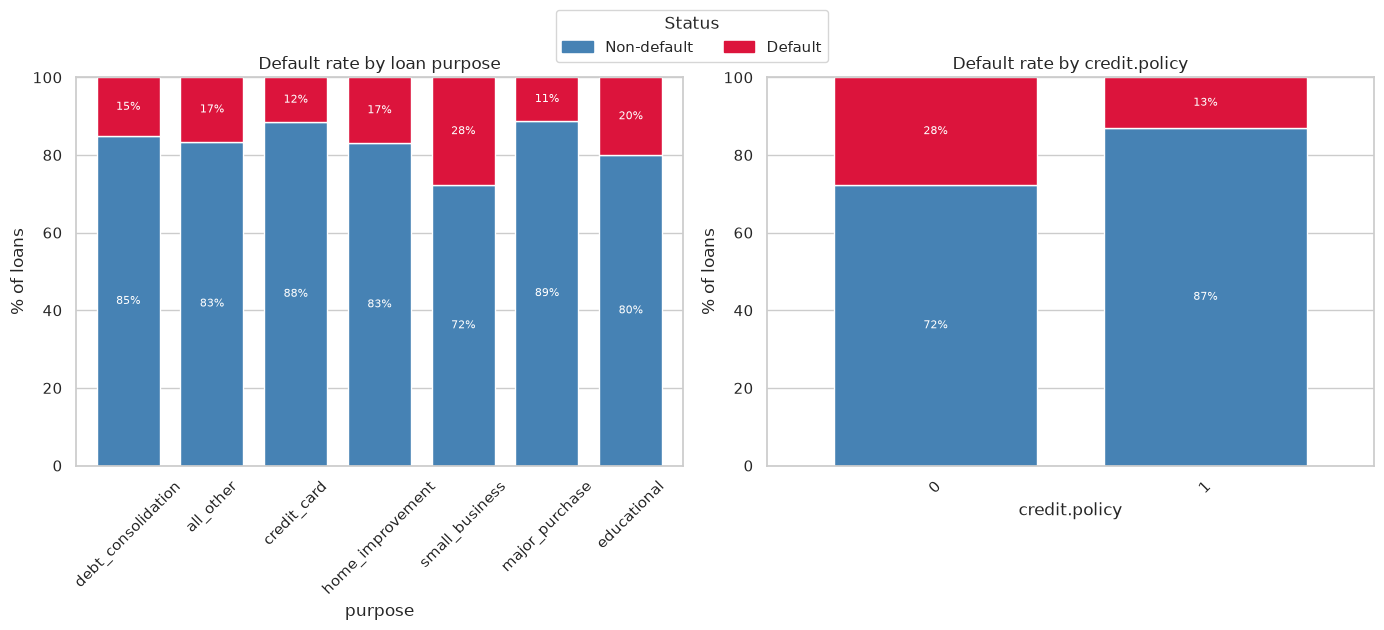

In [10]:
default_palette = {0: 'steelblue', 1: 'crimson'}
default_labels = {0: 'Non-default', 1: 'Default'}

def plot_100pct_stacked(ax, series, default, title, xlabel, order=None):
    tab = pd.crosstab(series, default, normalize='index') * 100
    if order is not None:
        tab = tab.reindex(order)
    tab = tab.rename(columns=default_labels)
    tab[[default_labels[0], default_labels[1]]].plot(
        kind='bar', stacked=True, ax=ax,
        color=[default_palette[0], default_palette[1]], width=0.75, legend=False)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('% of loans')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=45)
    for container in ax.containers:
        labels = [f'{v:.0f}%' if v >= 5 else '' for v in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=8, color='white')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
order = df['purpose'].value_counts().index
plot_100pct_stacked(axes[0], df['purpose'], df['default'], 'Default rate by loan purpose', 'purpose', order=order)
plot_100pct_stacked(axes[1], df['credit.policy'], df['default'], 'Default rate by credit.policy', 'credit.policy')
handles = [plt.Rectangle((0,0),1,1, color=default_palette[k]) for k in (0,1)]
fig.legend(handles, [default_labels[0], default_labels[1]], title='Status', loc='upper center',
           bbox_to_anchor=(0.5, 1.06), ncol=2)
plt.tight_layout()
plt.savefig('../output/categorical_normalized_by_default.png', dpi=150, bbox_inches='tight')
plt.show()


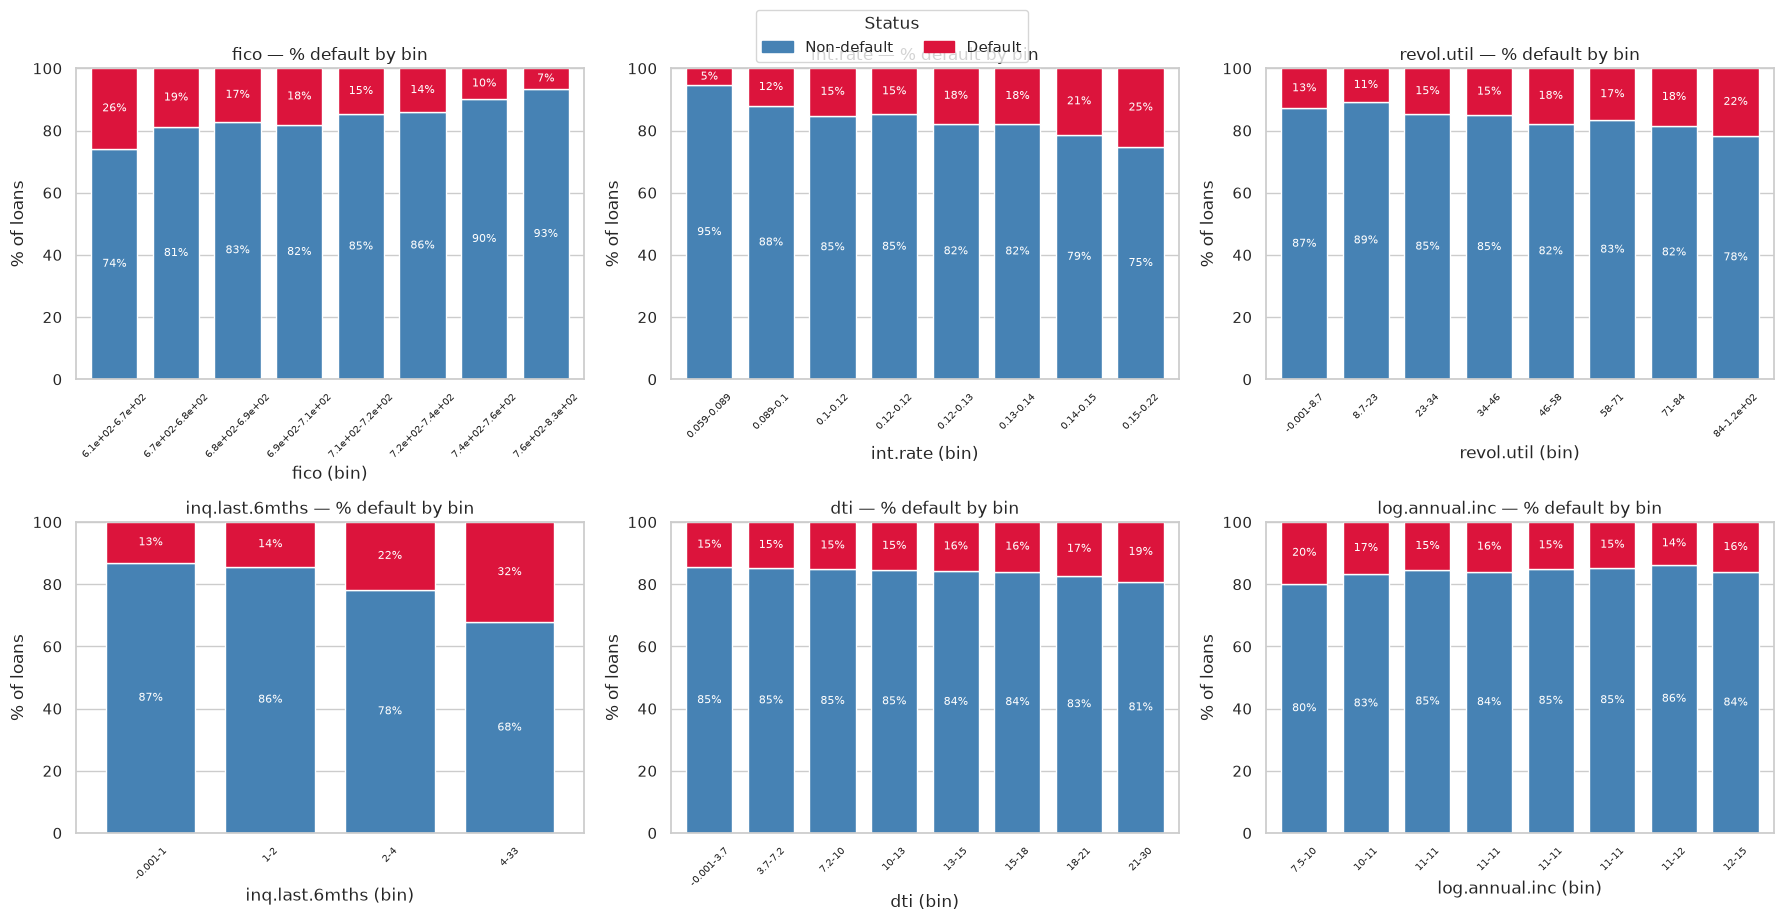

In [11]:
default_drivers = ['fico', 'int.rate', 'revol.util', 'inq.last.6mths', 'dti', 'log.annual.inc']
n_bins = 8
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(default_drivers):
    binned = pd.qcut(df[col], q=n_bins, duplicates='drop')
    bin_order = binned.cat.categories
    plot_100pct_stacked(axes[i], binned, df['default'], f'{col} — % default by bin', f'{col} (bin)', order=bin_order)
    axes[i].set_xticklabels([f'{iv.left:.2g}-{iv.right:.2g}' for iv in bin_order], fontsize=7)
handles = [plt.Rectangle((0,0),1,1, color=default_palette[k]) for k in (0,1)]
fig.legend(handles, [default_labels[0], default_labels[1]], title='Status', loc='upper center',
           bbox_to_anchor=(0.5, 1.03), ncol=2)
plt.tight_layout()
plt.savefig('../output/numerical_normalized_by_default.png', dpi=150, bbox_inches='tight')
plt.show()


**Findings:**
- **`purpose`**: `small_business` loans default at 27.8% — roughly 2.5x the
  rate of `major_purchase`/`credit_card` loans (~11%).
- **`credit.policy`**: loans failing LendingClub's own underwriting default
  at 27.8% vs. 13.2% for those that pass — a real but imperfect filter.
- **`fico`**: the cleanest monotonic gradient — default falls from ~26% in
  the lowest FICO octile to ~7% in the highest (~4x spread).
- **`int.rate`**: mirrors FICO, rising from ~5% to ~25% across octiles,
  since it is set as a function of assessed risk.
- **`revol.util`**: rises from ~11–13% to ~22% at the highest utilization —
  an over-leverage signal.
- **`inq.last.6mths`**: the steepest gradient of all, roughly tripling from
  ~13% (0–1 inquiries) to ~32% (5+ inquiries) — recent credit-shopping is a
  strong red flag.
- **`dti`** and **`log.annual.inc`**: comparatively flat, with only a mild
  uptick in the riskiest extreme bin — weaker standalone predictors.

These confirm the hypotheses in Section 3.3 and motivate the variable
choices for clustering and PCA below.


## 5. K-Means Clustering

Clustering lets us use the *co-varying* patterns among borrower attributes
to pick out naturally occurring segments of loan applications, independent
of the default label. These segments can later be used to stratify
modeling, spot-check risk models, or target growth/marketing efforts.

### 5.1 Variable selection

Following the case's own example set (interest rate, installment, annual
income, FICO score, revolving balance, revolving utilization), we cluster on
the **continuous, application-time numeric variables** that showed
meaningful spread and default-rate gradients above:

`int.rate`, `installment`, `log.annual.inc`, `dti`, `fico`,
`days.with.cr.line`, `revol.bal`, `revol.util`, `inq.last.6mths`

We deliberately **exclude** `credit.policy` (a binary underwriting flag,
not a continuous borrower attribute — and effectively downstream of the
other variables), and `delinq.2yrs`/`pub.rec` (Section 4.2 showed these are
overwhelmingly zero across the sample, so they carry almost no variance for
Euclidean-distance-based clustering and would just add noise).


In [12]:
cluster_vars = ['int.rate', 'installment', 'log.annual.inc', 'dti', 'fico',
                'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_vars])
print(f"Clustering on {X_scaled.shape[0]} loans x {X_scaled.shape[1]} scaled features")


Clustering on 9578 loans x 9 scaled features


### 5.2 Choosing the number of clusters (elbow + silhouette)

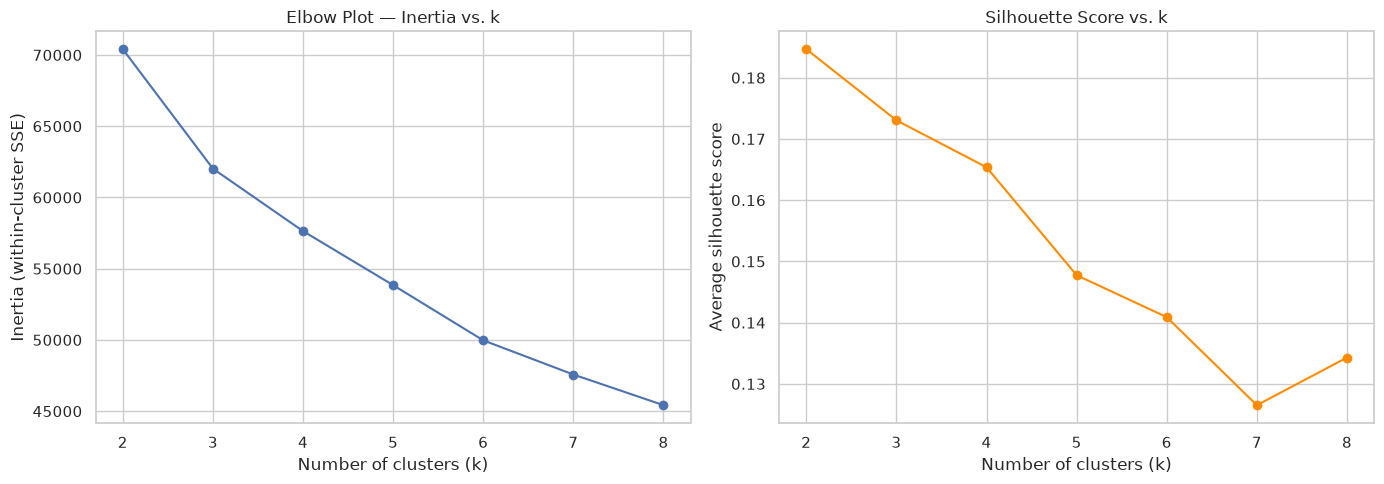

k=2: inertia=70411, silhouette=0.1847
k=3: inertia=62024, silhouette=0.1730
k=4: inertia=57640, silhouette=0.1654
k=5: inertia=53847, silhouette=0.1477
k=6: inertia=49973, silhouette=0.1409
k=7: inertia=47574, silhouette=0.1265
k=8: inertia=45423, silhouette=0.1343


In [13]:
k_range = range(2, 9)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow Plot — Inertia vs. k')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].grid(True)

axes[1].plot(list(k_range), silhouettes, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score vs. k')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Average silhouette score')
axes[1].grid(True)
plt.tight_layout()
plt.savefig('../output/kmeans_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

for k, inertia, sil in zip(k_range, inertias, silhouettes):
    print(f"k={k}: inertia={inertia:.0f}, silhouette={sil:.4f}")


Silhouette scores are modest throughout (typical for real-world borrower
data with overlapping, continuous risk gradients rather than tight natural
clusters), and both the elbow and silhouette curves flatten out after
**k=4**. We proceed with **k=4** clusters — few enough to name and act on,
while still separating out a distinct high-balance outlier segment (see
below).

### 5.3 Fit K-means with k=4 and profile the clusters


In [14]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_sizes = df['cluster'].value_counts().sort_index()
cluster_sizes_pct = (cluster_sizes / len(df) * 100).round(1)
print("Cluster sizes:")
display(pd.DataFrame({'n_loans': cluster_sizes, '% of loans': cluster_sizes_pct}))

cluster_profile = df.groupby('cluster')[cluster_vars].mean().round(2)
cluster_profile['default_rate_%'] = (df.groupby('cluster')['default'].mean() * 100).round(1)
cluster_profile['credit_policy_pass_%'] = (df.groupby('cluster')['credit.policy'].mean() * 100).round(1)
display(cluster_profile)


Cluster sizes:


,n_loans,% of loans
cluster,,
0,187,2.0
1,3074,32.1
2,2625,27.4
3,3692,38.5


,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,default_rate_%,credit_policy_pass_%
cluster,,,,,,,,,,,
0,0.13,500.24,11.99,16.68,715.96,7040.56,191519.29,57.39,1.99,28.3,18.7
1,0.10,278.38,10.95,9.33,750.84,5140.49,9500.39,22.16,1.09,8.8,95.3
2,0.14,507.95,11.34,14.64,698.79,5623.88,24986.81,63.32,1.58,18.0,82.1
3,0.13,209.53,10.57,13.68,685.85,3196.61,8503.05,55.03,1.96,20.0,70.2


### 5.4 Naming the clusters — parallel-coordinates plot of (standardized) cluster centers

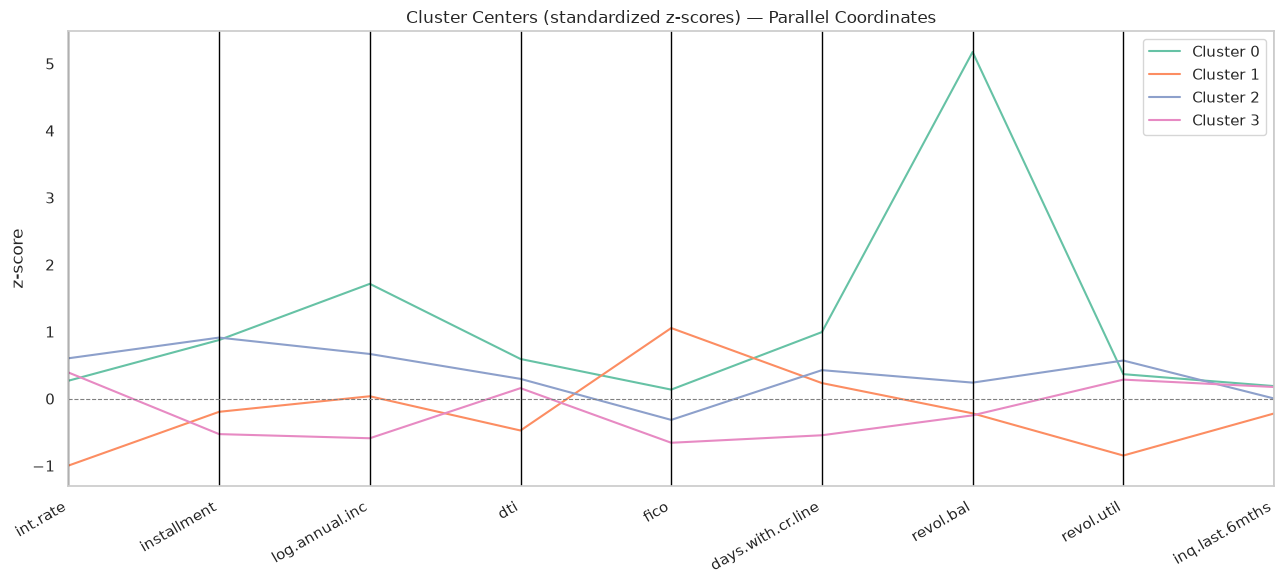

In [15]:
centers_df = pd.DataFrame(kmeans.cluster_centers_, columns=cluster_vars)
centers_df['cluster'] = [f'Cluster {i}' for i in range(len(centers_df))]

plt.figure(figsize=(13, 6))
parallel_coordinates(centers_df, 'cluster', color=sns.color_palette('Set2', 4))
plt.title('Cluster Centers (standardized z-scores) — Parallel Coordinates')
plt.ylabel('z-score')
plt.xticks(rotation=30, ha='right')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../output/kmeans_parallel_coordinates.png', dpi=150, bbox_inches='tight')
plt.show()


**Cluster interpretation (naming), based on the standardized centers and
raw-unit profile table above:**

| Cluster | Size | Distinguishing features | Default rate | Name |
|---|---|---|---|---|
| **1** | 3,074 (32%) | Lowest `int.rate` (10%), highest `fico` (~751), lowest `revol.util` (~22%), lowest `dti`; 95% pass `credit.policy` | **8.8%** (safest) | **"High-FICO, low-rate safe borrowers"** |
| **2** | 2,625 (27%) | Highest `int.rate` (14%), highest `revol.util` (~63%), large installments, above-average income | 18.0% | **"High-utilization revolvers"** |
| **3** | 3,692 (39%, largest) | Smallest loans (`installment` ~$210), lowest income, shortest credit history (~3,200 days), lowest `fico` (~686), highest `inq.last.6mths` | 20.0% | **"Short-history, small-loan borrowers"** |
| **0** | 187 (2%, small outlier segment) | Extreme `revol.bal` (z ≈ +5.2, mean ~$191.5k), highest income, long credit history, only 18.7% pass `credit.policy` | **28.3%** (riskiest) | **"High-income jumbo revolvers"** |

Clusters 1–3 line up almost exactly with the three archetypes suggested by
the case ("high-FICO low-rate safe borrowers," "high-utilization
revolvers," "short-history small-purchase borrowers"). Cluster 0 is a small
but important outlier segment: high-income borrowers carrying unusually
large absolute revolving balances, who — despite decent FICO scores — fail
LendingClub's credit policy at a high rate and default the most often.

### 5.5 How this clustering guides future modeling

- It gives a **natural, unsupervised risk stratification** independent of
  the `default` label — useful to sanity-check that a later logistic
  regression / tree model's predicted risk ranks track these segments.
- Cluster 0 (jumbo revolvers) flags a **specific, low-frequency but
  high-impact risk pattern** driven by an extreme value of a single
  variable (`revol.bal`) that a linear model might under-weight — worth
  testing as an explicit interaction/flag (e.g., `revol.bal` above some
  threshold) in Update 2's models.
- Cluster 3 (short-history, small-loan borrowers) is both the **largest
  segment (39% of volume)** and above-average risk — a natural target for
  tighter screening rules and for the CMO's growth strategy (e.g.,
  requiring longer credit history or smaller initial loan sizes for this
  segment).
- Segment membership itself could become an **engineered categorical
  feature** for the classification models in Update 2.


## 6. Principal Component Analysis (PCA)

PCA highlights weighted combinations of the numeric variables that capture
the directions of highest variability among loans — a complementary,
continuous view to the discrete segments found by K-means.

### 6.1 Variable selection

We use the **same 9 numeric, application-time variables** as the K-means
analysis (`int.rate`, `installment`, `log.annual.inc`, `dti`, `fico`,
`days.with.cr.line`, `revol.bal`, `revol.util`, `inq.last.6mths`) — chosen
for the same reasons: they are known at application time, show real
variation, and (per Section 4) carry the strongest default-rate signal. This
consistency also lets us compare the clustering and PCA views of the same
feature space directly.


In [16]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = explained_variance_ratio.cumsum()

print('Explained variance ratio per component:')
for i, ratio in enumerate(explained_variance_ratio):
    print(f'PC{i+1}: {ratio*100:.2f}%')
print('\nCumulative explained variance:')
for i, cum in enumerate(cumulative_explained_variance):
    print(f'PC{i+1}: {cum*100:.2f}%')

pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
pca_df['default'] = df['default'].values
pca_df['cluster'] = df['cluster'].values
display(pca_df.head())


Explained variance ratio per component:
PC1: 27.03%
PC2: 21.94%
PC3: 12.20%
PC4: 10.48%
PC5: 8.16%
PC6: 7.81%
PC7: 5.42%
PC8: 4.85%
PC9: 2.12%

Cumulative explained variance:
PC1: 27.03%
PC2: 48.96%
PC3: 61.16%
PC4: 71.65%
PC5: 79.80%
PC6: 87.61%
PC7: 93.03%
PC8: 97.88%
PC9: 100.00%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,default,cluster
0,0.293519,2.129037,-0.439292,-0.901452,-1.416452,-0.946758,0.044125,0.483648,-0.342046,0,2
1,0.307183,-0.135556,-1.018111,-0.382809,0.915562,-0.418467,0.767415,0.302738,-0.094605,0,3
2,0.125693,-0.752596,0.222928,-0.366867,-0.527189,0.169821,-1.020453,-0.414287,-0.436702,0,3
3,-0.178974,-0.062634,-0.282995,-0.257480,1.566777,-0.097738,1.019344,0.370671,-0.054586,0,3
4,0.723781,-0.664296,-0.319891,-0.357139,0.325424,0.521827,0.293936,-1.592827,0.041439,0,3


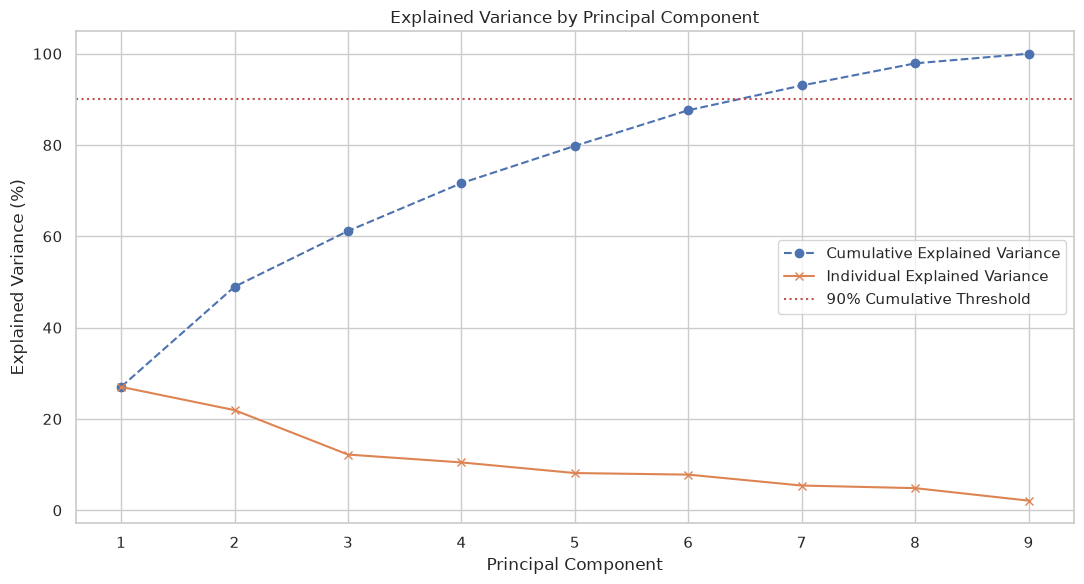

In [17]:
num_components = range(1, len(cumulative_explained_variance) + 1)

plt.figure(figsize=(11, 6))
plt.plot(num_components, cumulative_explained_variance * 100, marker='o', linestyle='--',
         label='Cumulative Explained Variance')
plt.plot(num_components, explained_variance_ratio * 100, marker='x', linestyle='-',
         label='Individual Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Explained Variance by Principal Component')
plt.grid(True)
plt.xticks(num_components)
plt.axhline(y=90, color='r', linestyle=':', label='90% Cumulative Threshold')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('../output/pca_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2 Model-driven interpretation — variable loadings

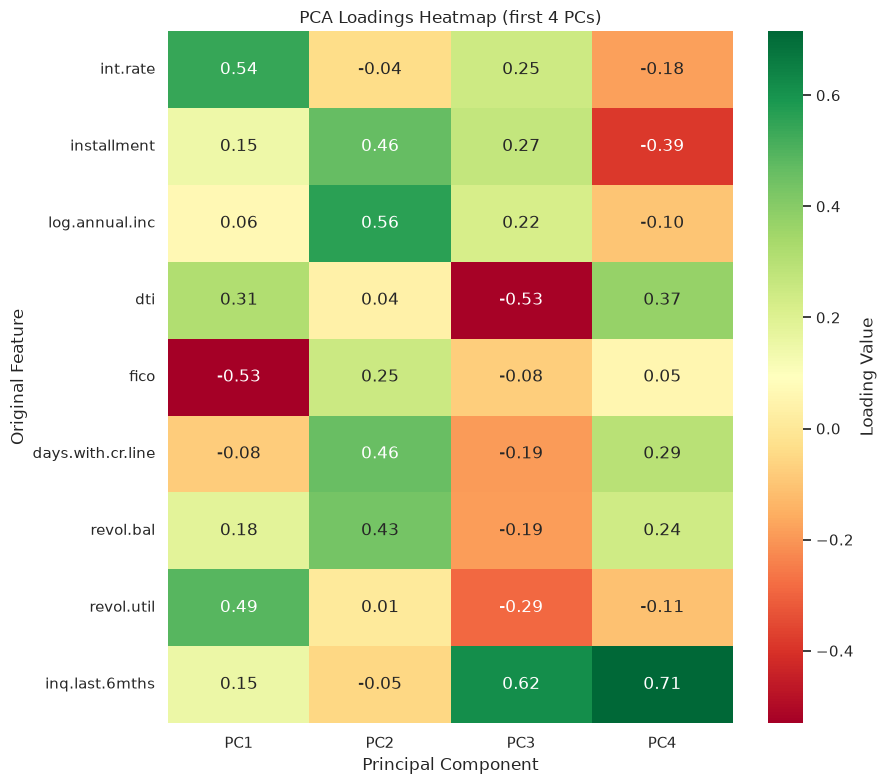

Top |loadings| for PC1:
  int.rate: +0.542
  fico: -0.530
  revol.util: +0.487
  dti: +0.314

Top |loadings| for PC2:
  log.annual.inc: +0.562
  installment: +0.464
  days.with.cr.line: +0.461
  revol.bal: +0.434

Top |loadings| for PC3:
  inq.last.6mths: +0.616
  dti: -0.525
  revol.util: -0.288
  installment: +0.270



In [18]:
loadings_df = pd.DataFrame(pca.components_, columns=cluster_vars,
                            index=[f'PC{i+1}' for i in range(pca.n_components_)])

n_show = min(4, loadings_df.shape[0])
plt.figure(figsize=(9, 8))
sns.heatmap(loadings_df.iloc[:n_show].T, annot=True, cmap='RdYlGn', fmt=".2f",
            cbar_kws={'label': 'Loading Value'})
plt.title(f'PCA Loadings Heatmap (first {n_show} PCs)')
plt.xlabel('Principal Component')
plt.ylabel('Original Feature')
plt.tight_layout()
plt.savefig('../output/pca_loadings_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

for pc in ['PC1', 'PC2', 'PC3']:
    top = loadings_df.loc[pc].abs().sort_values(ascending=False).head(4)
    print(f"Top |loadings| for {pc}:")
    for feat in top.index:
        print(f"  {feat}: {loadings_df.loc[pc, feat]:+.3f}")
    print()


**PC1 ("risk/pricing axis", 27.0% of variance):** dominant positive
loadings on `int.rate` (+0.54) and `revol.util` (+0.49), and a dominant
negative loading on `fico` (-0.53), with `dti` also positive (+0.31). High
PC1 = higher rate, higher utilization, higher debt-to-income, lower FICO —
i.e., a riskier borrower. This closely echoes the correlation findings in
Section 4.3.

**PC2 ("scale/establishment axis", 21.9% of variance, cumulative 49.0%):**
dominant positive loadings on `log.annual.inc` (+0.56), `installment`
(+0.46), `days.with.cr.line` (+0.46), and `revol.bal` (+0.43). High PC2 =
higher income, bigger loan, longer credit history, larger absolute balances
— a borrower "size"/tenure axis, largely orthogonal to risk.

Together PC1+PC2 explain about 49% of the variance; ~6 of the 9 components
are needed to reach 90% (variance is fairly evenly spread — consistent with
9 genuinely distinct underlying borrower attributes rather than a few
redundant ones).

### 6.3 Biplot of PC1 vs. PC2


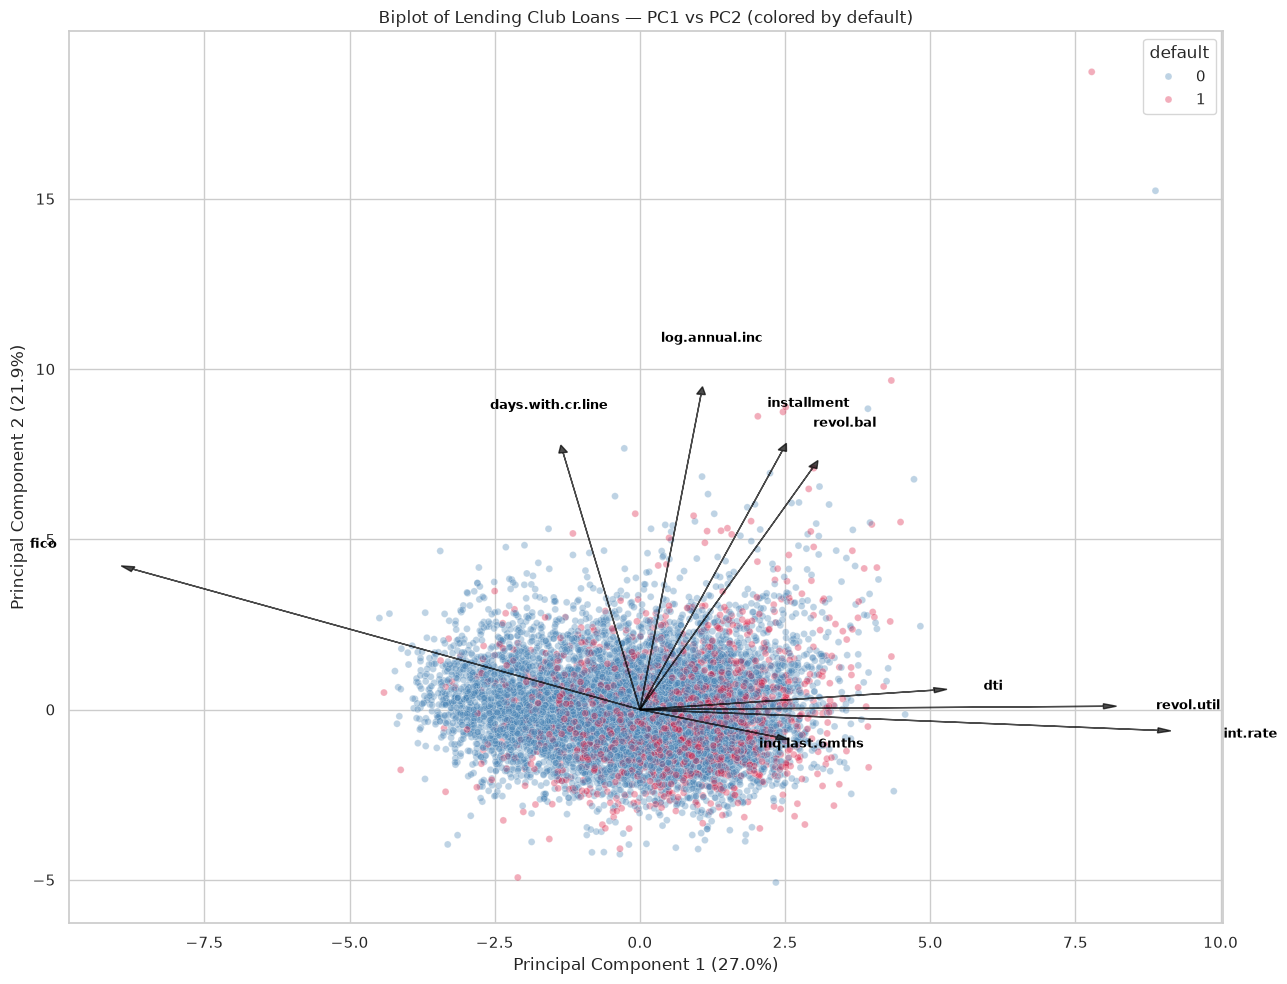

In [19]:
loadings = pca.components_
feature_names = cluster_vars

fig = plt.figure(figsize=(13, 10))
sns.scatterplot(x=pca_df['PC1'], y=pca_df['PC2'], hue=pca_df['default'],
                 palette={0: 'steelblue', 1: 'crimson'}, alpha=0.35, s=25)

scale = np.abs(pca_df[['PC1', 'PC2']]).max().max() * 0.9
for i, feature in enumerate(feature_names):
    plt.arrow(0, 0, loadings[0, i] * scale, loadings[1, i] * scale,
              color='black', alpha=0.7, head_width=0.15, length_includes_head=True)
    plt.text(loadings[0, i] * scale * 1.15, loadings[1, i] * scale * 1.15, feature,
              color='black', ha='center', va='center', fontsize=9, fontweight='bold')

plt.xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.1f}%)')
plt.title('Biplot of Lending Club Loans — PC1 vs PC2 (colored by default)')
plt.legend(title='default', loc='best')
plt.grid(True)
plt.tight_layout()
plt.savefig('../output/pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.4 Data-driven interpretation — examining extreme points

In [20]:
inspect_cols = cluster_vars + ['purpose', 'credit.policy', 'default']

for pc in ['PC1', 'PC2']:
    idx_max, idx_min = pca_df[pc].idxmax(), pca_df[pc].idxmin()
    print(f"=== Extreme HIGH {pc} (loan #{idx_max}, {pc}={pca_df.loc[idx_max, pc]:.2f}) ===")
    display(df.loc[[idx_max], inspect_cols])
    print(f"=== Extreme LOW {pc} (loan #{idx_min}, {pc}={pca_df.loc[idx_min, pc]:.2f}) ===")
    display(df.loc[[idx_min], inspect_cols])


=== Extreme HIGH PC1 (loan #9042, PC1=8.88) ===


,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,purpose,credit.policy,default
9042,0.2011,735.06,13.304685,14.39,672,7620.0,952013,99.0,6,small_business,0,0


=== Extreme LOW PC1 (loan #113, PC1=-4.49) ===


,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,purpose,credit.policy,default
113,0.0712,64.96,11.608236,0.22,812,16213.0,50,0.3,0,debt_consolidation,1,0


=== Extreme HIGH PC2 (loan #9535, PC2=18.73) ===


,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,purpose,credit.policy,default
9535,0.1496,831.52,12.765688,11.38,717,8520.041667,1207359,56.0,7,small_business,0,1


=== Extreme LOW PC2 (loan #7822, PC2=-5.08) ===


,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,purpose,credit.policy,default
7822,0.1722,64.38,7.547502,18.99,642,450.0,702,87.7,0,debt_consolidation,0,0


**Reading the extremes confirms the model-driven story:**

- **Highest PC1** loan: `int.rate` = 20.1%, `revol.util` = 99%, `fico` = 672,
  `revol.bal` ≈ $952k, a `small_business` loan that **fails** `credit.policy`
  — exactly the risk profile PC1 is built to flag, though this particular
  loan happened not to default (a reminder that PC1 is a risk *tendency*,
  not a certainty).
- **Lowest PC1** loan: `int.rate` = 7.1%, `revol.util` = 0.3%, `fico` = 812,
  `dti` ≈ 0 — a textbook ultra-safe borrower, and indeed did not default.
- **Highest PC2** loan: `log.annual.inc` ≈ $600k (log 12.77), installment
  $831.52, `revol.bal` at the data's maximum ($1,207,359) — a very large,
  established, high-income `small_business` borrower. Interestingly this
  loan **did** default, showing PC2 (size) is not itself protective once
  PC1-type risk factors are also present.
- **Lowest PC2** loan: very low income (log 7.55, i.e., ~$1,900/yr — a
  clear outlier/data-quality flag), very short credit history (450 days),
  and high `revol.util` (87.7%) — a young/short-history, high-utilization
  borrower.

These examples show PC1 and PC2 behave as intended (a risk axis and a
scale/establishment axis, respectively), and surface individual loans worth
spot-checking for data quality (e.g., the very low reported income case).

### 6.5 How this PCA guides future modeling

- **PC1 is a ready-made, single-number risk score** built purely from
  unsupervised structure — a useful baseline/sanity-check against the
  logistic regression coefficients we will estimate in Update 2 (do the
  same variables dominate?).
- **Near-orthogonality of PC1 and PC2** suggests `int.rate`/`fico`/
  `revol.util`/`dti` (risk) and `log.annual.inc`/`installment`/
  `days.with.cr.line`/`revol.bal` (scale) are two largely independent
  dimensions — both may be worth retaining as predictors rather than
  assuming one subsumes the other.
- The **PCA loadings mirror the correlation findings** (Section 4.3) and
  the **K-means cluster centers** (Section 5) — three independent views of
  the data (correlation, clustering, PCA) converge on the same handful of
  variables (`fico`, `int.rate`, `revol.util`, `dti`) as the primary risk
  drivers, giving confidence in the variable set to carry into Update 2's
  classification models.
- PCA could also be used for **dimensionality reduction** if
  multicollinearity becomes a problem in the logistic regression (e.g.,
  using PC1/PC2 scores directly as predictors), though we would trade off
  some interpretability for the ExCo audience.


## 7. Synthesis — Update 1 Summary for the ExCo

**Business problem:** we are building the analytical groundwork to screen
loan applications for default risk *before* they are shown to investors —
directly supporting the CEO (ROIC), CFO (interest profit), and CMO (market
share via better investor outcomes).

**Data understanding:** 9,578 three-year loans, 16.0% historical default
rate, no missing values. Thirteen fields are known at application time; the
KPI fields (`tot.payment`, `principal`, `interest`) are computed only after
the outcome is known and must be excluded from any funding-decision model.

**Descriptive findings:** default rate varies substantially and often
monotonically with `fico` (~26% → ~7%), `int.rate` (~5% → ~25%),
`revol.util` (~12% → ~22%), and especially `inq.last.6mths` (~13% → ~32%);
`purpose` (`small_business` at 27.8% vs. `major_purchase` at 11.2%) and
`credit.policy` (27.8% vs. 13.2%) are also strong discriminators. `dti` and
`log.annual.inc` are weaker, more tail-driven signals.

**Clustering:** four borrower segments emerge from K-means on 9 scaled
numeric features — matching the case's own suggested archetypes almost
exactly: **safe high-FICO borrowers** (33%, 8.8% default), **high-utilization
revolvers** (27%, 18.0% default), **short-history small-loan borrowers**
(39%, 20.0% default, the largest segment), and a small but important
**high-income jumbo-revolver** outlier segment (2%, 28.3% default — the
riskiest of all).

**PCA:** two dominant, largely independent components — a **risk/pricing
axis** (`int.rate`, `fico`, `revol.util`, `dti`) and a **scale/establishment
axis** (`log.annual.inc`, `installment`, `days.with.cr.line`, `revol.bal`) —
together explain ~49% of variance and corroborate the correlation and
clustering findings.

**Convergent conclusion:** three independent descriptive lenses
(correlation analysis, K-means, and PCA) all point to the same core set of
risk drivers — `fico`, `int.rate`, `revol.util`, `dti`, and
`inq.last.6mths` — plus `purpose` and `credit.policy` as categorical
discriminators. This gives us a well-supported, ExCo-defensible variable
shortlist to carry into Update 2's logistic regression and decision-tree
default models.
